# A notebook for article abstracts classification with NLP


### 1. Install dependencies

In [1]:
!pip install -q transformers scikit-learn pandas matplotlib seaborn

In [2]:
!pip install "datasets<4.0" #avoids a data loading problem

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 31.6 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


### 2. Load data

In [3]:
from datasets import load_dataset
dataset = load_dataset("nick007x/arxiv-papers")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.parquet:   0%|          | 0.00/1.70G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2549619 [00:00<?, ? examples/s]

### Examine data fields

In [4]:
print(dataset)
print(dataset["train"].features)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['arxiv_id', 'title', 'authors', 'submission_date', 'comments', 'primary_subject', 'subjects', 'doi', 'abstract', 'file_path'],
        num_rows: 2549619
    })
})
{'arxiv_id': Value(dtype='string', id=None), 'title': Value(dtype='string', id=None), 'authors': [Value(dtype='string', id=None)], 'submission_date': Value(dtype='string', id=None), 'comments': Value(dtype='string', id=None), 'primary_subject': Value(dtype='string', id=None), 'subjects': Value(dtype='string', id=None), 'doi': Value(dtype='string', id=None), 'abstract': Value(dtype='string', id=None), 'file_path': Value(dtype='string', id=None)}
{'arxiv_id': '0902.3253', 'title': 'The gravitational wave background from star-massive black hole fly-bys', 'authors': ['Silvia Toonen', 'Clovis Hopman', 'Marc Freitag'], 'submission_date': '18 Feb 2009 (<a href="https://arxiv.org/abs/0902.3253v1">v1</a>), last revised 18 Jun 2009 (this version, v2)', 'comments': 'Accepted for publ

### 3. Create labels

We will do a multiclass classification based on the subject. Let's first examine the possibilities to generate the labels.

In [5]:
unique_subjects = set(dataset["train"][:]['primary_subject'])
len(unique_subjects)

148

In [6]:
print(unique_subjects)

{'Neurons and Cognition (q-bio.NC)', 'Superconductivity (cond-mat.supr-con)', 'Numerical Analysis (math.NA)', 'High Energy Physics - Experiment (hep-ex)', 'Optimization and Control (math.OC)', 'Fluid Dynamics (physics.flu-dyn)', 'Methodology (stat.ME)', 'Risk Management (q-fin.RM)', 'Cellular Automata and Lattice Gases (nlin.CG)', 'High Energy Physics - Phenomenology (hep-ph)', 'Data Analysis, Statistics and Probability (physics.data-an)', 'Molecular Networks (q-bio.MN)', 'Algebraic Geometry (math.AG)', 'Statistical Mechanics (cond-mat.stat-mech)', 'Neural and Evolutionary Computing (cs.NE)', 'Digital Libraries (cs.DL)', 'Materials Science (cond-mat.mtrl-sci)', 'Graphics (cs.GR)', 'Quantum Algebra (math.QA)', 'Computer Vision and Pattern Recognition (cs.CV)', 'Medical Physics (physics.med-ph)', 'Computational Finance (q-fin.CP)', 'Atomic and Molecular Clusters (physics.atm-clus)', 'Algebraic Topology (math.AT)', 'Category Theory (math.CT)', 'History and Overview (math.HO)', 'Atomic Phy

148 is too much for the task. Let's extract main categories using regular expressions.

In [7]:
import re

def extract_main_category(subject):
    """
    Extracts main arXiv category from:
    'Operating Systems (cs.OS)' -> 'cs'
    'Quantum Physics (quant-ph)' -> 'quant-ph'
    """
    # Find content within parentheses, e.g., "cs.OS" or "quant-ph"
    match = re.search(r"\((.*?)\)", subject)

    if match:
        category_full = match.group(1) # e.g., "cs.OS" or "quant-ph"
        # Split by the first dot and take the first part. If no dot, it returns the full string.
        return category_full.split(".")[0]
    else:
        return None

In [8]:
examples = [
    "Formal Languages and Automata Theory (cs.FL)",
    "Computation (stat.CO)",
    "Operating Systems (cs.OS)",
    "High Energy Physics - Phenomenology (hep-ph)"
]

for e in examples:
    print(extract_main_category(e))

cs
stat
cs
hep-ph


Adding a new column for main category.

In [9]:
def add_main_category(example):
    example["main_category"] = extract_main_category(example["primary_subject"])
    return example

dataset = dataset.map(add_main_category)

Map:   0%|          | 0/2549619 [00:00<?, ? examples/s]

In [10]:
dataset["train"][0]

{'arxiv_id': '0902.3253',
 'title': 'The gravitational wave background from star-massive black hole fly-bys',
 'authors': ['Silvia Toonen', 'Clovis Hopman', 'Marc Freitag'],
 'submission_date': '18 Feb 2009 (<a href="https://arxiv.org/abs/0902.3253v1">v1</a>), last revised 18 Jun 2009 (this version, v2)',
 'comments': 'Accepted for publication by MNRAS; New appendix on population of phase space in presence of gravitational wave inspiral',
 'primary_subject': 'Earth and Planetary Astrophysics (astro-ph.EP)',
 'subjects': 'Earth and Planetary Astrophysics (astro-ph.EP)',
 'doi': 'https://doi.org/10.48550/arXiv.0902.3253',
 'abstract': 'Stars on eccentric orbits around a massive black hole (MBH) emit bursts of gravitational waves (GWs) at periapse. Such events may be directly resolvable in the Galactic centre. However, if the star does not spiral in, the emitted GWs are not resolvable for extra-galactic MBHs, but constitute a source of background noise. We estimate the power spectrum of t

In [11]:
from collections import Counter

Counter(dataset["train"]["main_category"])

Counter({'astro-ph': 227757,
         'cond-mat': 322843,
         'eess': 69341,
         'cs': 622419,
         'math': 535240,
         'econ': 9914,
         'hep-ex': 24161,
         'hep-lat': 16886,
         'hep-ph': 116920,
         'hep-th': 93277,
         'nlin': 23440,
         'nucl-ex': 12073,
         'nucl-th': 34644,
         'physics': 166441,
         'q-bio': 31942,
         'q-fin': 12066,
         'gr-qc': 53865,
         'quant-ph': 120051,
         'stat': 56339})

To simplify the task further, we can unite certain categories under one umbrella.

In [12]:
DOMAIN_MAP = {
    "cs": "cs",
    "eess": "cs",

    "math": "math",
    "stat": "math",
    "nlin": "math",

    "physics": "physics",
    "cond-mat": "physics",
    "quant-ph": "physics",
    "astro-ph": "physics",
    "gr-qc": "physics",

    "hep-ex": "hep",
    "hep-ph": "hep",
    "hep-th": "hep",
    "hep-lat": "hep",

    "nucl-ex": "nucl",
    "nucl-th": "nucl",

    "q-bio": "q-bio",
    "q-fin": "q-fin",
    "econ": "econ",
}

In [13]:
def remap_category(example):
    example["label"] = DOMAIN_MAP.get(example["main_category"], "other")
    return example

dataset = dataset.map(remap_category)

Map:   0%|          | 0/2549619 [00:00<?, ? examples/s]

We keep both article name and abstract for the prediction. The rest of the data is not necessary and can be removed from the table.

In [14]:
def combine_text(example):
    example["text"] = example["title"] + ". " + example["abstract"]
    return example

dataset = dataset.map(combine_text)

Map:   0%|          | 0/2549619 [00:00<?, ? examples/s]

In [15]:
keep_columns = ["text", "label"]

clean_dataset = dataset.remove_columns(
    [col for col in dataset["train"].column_names if col not in keep_columns]
)
clean_dataset["train"][0]

{'label': 'physics',
 'text': 'The gravitational wave background from star-massive black hole fly-bys. Stars on eccentric orbits around a massive black hole (MBH) emit bursts of gravitational waves (GWs) at periapse. Such events may be directly resolvable in the Galactic centre. However, if the star does not spiral in, the emitted GWs are not resolvable for extra-galactic MBHs, but constitute a source of background noise. We estimate the power spectrum of this extreme mass ratio burst background (EMBB) and compare it to the anticipated instrumental noise of the Laser Interferometer Space Antenna (LISA). To this end, we model the regions close to a MBH, accounting for mass-segregation, and for processes that limit the presence of stars close to the MBH, such as GW inspiral and hydrodynamical collisions between stars. We find that the EMBB is dominated by GW bursts from stellar mass black holes, and the magnitude of the noise spectrum (f S_GW)^{1/2} is at least a factor ~10 smaller than 

### 4. EDA

In [16]:
import pandas as pd

label_counts = Counter(clean_dataset["train"]["label"])
label_counts

Counter({'physics': 890957,
         'cs': 691760,
         'math': 615019,
         'econ': 9914,
         'hep': 251244,
         'nucl': 46717,
         'q-bio': 31942,
         'q-fin': 12066})

In [17]:
df_counts = pd.DataFrame(
    label_counts.items(),
    columns=["label", "count"]
).sort_values("count", ascending=False)

df_counts["percentage"] = df_counts["count"]/len(clean_dataset["train"])
df_counts

,label,count,percentage
0,physics,890957,0.349447
1,cs,691760,0.271319
2,math,615019,0.241220
4,hep,251244,0.098542
5,nucl,46717,0.018323
6,q-bio,31942,0.012528
7,q-fin,12066,0.004732
3,econ,9914,0.003888


We can observe a significant class imbalance in the dataset.

In [18]:
import numpy as np

text_lengths = [
    len(t) for t in clean_dataset["train"]["text"]
]

pd.Series(text_lengths).describe()

,0
count,2.549619e+06
mean,1.059329e+03
std,4.435757e+02
min,3.200000e+01
25%,7.150000e+02
50%,1.033000e+03
75%,1.378000e+03
max,6.626000e+03


In [19]:
token_lengths = [
    len(t.split()) for t in clean_dataset["train"]["text"]
]

pd.Series(token_lengths).describe()

,0
count,2.549619e+06
mean,1.531849e+02
std,6.402366e+01
min,5.000000e+00
25%,1.040000e+02
50%,1.490000e+02
75%,1.980000e+02
max,9.690000e+02


In [20]:
df_lengths = pd.DataFrame({
    "label": clean_dataset["train"]["label"],
    "length": token_lengths
})

df_lengths.groupby("label")["length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
cs,691760.0,178.304437,52.372656,8.0,143.0,177.0,213.0,607.0
econ,9914.0,158.128808,55.034203,8.0,116.0,153.0,193.0,514.0
hep,251244.0,121.601726,54.281487,5.0,82.0,113.0,153.0,436.0
math,615019.0,118.561810,58.963894,6.0,74.0,109.0,155.0,666.0
nucl,46717.0,133.975919,56.392142,10.0,93.0,126.0,167.0,536.0
physics,890957.0,166.223465,64.572432,6.0,116.0,159.0,212.0,969.0
q-bio,31942.0,187.041763,59.220053,5.0,145.0,187.0,231.0,542.0
q-fin,12066.0,153.384220,57.242850,12.0,111.0,147.0,190.0,631.0


Sanity check:

In [21]:
import random

def show_examples(dataset, label, n=3):
    examples = [
        x for x in dataset["train"]
        if x["label"] == label
    ]
    for ex in random.sample(examples, n):
        print(ex["text"][:500])
        print("-" * 80)

# Example: physics
show_examples(clean_dataset, label="physics")

Resolved shock structure of the Balmer-dominated filaments in Tycho&#39;s supernova remnant: Cosmic-ray precursor?. We report on the results from H{\alpha} imaging observations of the eastern limb of Tycho&#39;s supernova remnant (SN1572) using the Wide Field Planetary Camera 2 on the Hubble Space Telescope. We resolve the detailed structure of the fast, collisionless shock wave into a delicate structure of nearly edge-on filaments. We find a gradual increase of H{\alpha} intensity just ahead of
--------------------------------------------------------------------------------
Energy-Momentum Tensor of Particles Created in an Expanding Universe. We present a general formulation of the time-dependent initial value problem for a quantum scalar field of arbitrary mass and curvature coupling in a FRW cosmological model. We introduce an adiabatic number basis which has the virtue that the divergent parts of the quantum expectation value of the energy-momentum tensor &lt;T_ab&gt; are isolated 

### 5. Data cleaning

Removal of duplicates:

In [22]:
texts = clean_dataset["train"]["text"]
dup_rate = 1 - len(set(texts)) / len(texts)
dup_rate

0.00010472152898144405

In [23]:
import hashlib

def text_hash(t: str) -> str:
    return hashlib.md5(t.encode("utf-8")).hexdigest()

seen = set()
def keep_unique(example):
    h = text_hash(example["text"])
    if h in seen:
        return False
    seen.add(h)
    return True

clean_dataset["train"] = clean_dataset["train"].filter(keep_unique, num_proc=1)

Filter:   0%|          | 0/2549619 [00:00<?, ? examples/s]

In [24]:
texts = clean_dataset["train"]["text"]
dup_rate = 1 - len(set(texts)) / len(texts)
dup_rate

0.0

Encode labels for classification:

In [25]:
clean_dataset["train"].features

{'label': Value(dtype='string', id=None),
 'text': Value(dtype='string', id=None)}

In [26]:
clean_dataset = clean_dataset.class_encode_column("label")

Flattening the indices:   0%|          | 0/2549352 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/2549352 [00:00<?, ? examples/s]

In [27]:
# Store label names immediately after encoding for consistent reference
LABEL_NAMES = clean_dataset["train"].features["label"].names
NUM_LABELS = len(LABEL_NAMES)
print(f"Label names: {LABEL_NAMES}")
print(f"Number of labels: {NUM_LABELS}")

Label names: ['cs', 'econ', 'hep', 'math', 'nucl', 'physics', 'q-bio', 'q-fin']
Number of labels: 8


### Train-validation-test split:

In [28]:
from datasets import DatasetDict

# First: split off test set (10%)
tmp = clean_dataset["train"].train_test_split(
    test_size=0.10,
    seed=42,
    stratify_by_column="label"
)

# Second: split remaining 90% into train (80%) and validation (10%)
# We want val to be 10% of total -> that's 10/90 = 1/9 of tmp["train"]
split2 = tmp["train"].train_test_split(
    test_size=1/9,
    seed=42,
    stratify_by_column="label"
)

clean_dataset = DatasetDict({
    "train": split2["train"],
    "validation": split2["test"],
    "test": tmp["test"]
})

clean_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 2039480
    })
    validation: Dataset({
        features: ['label', 'text'],
        num_rows: 254936
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 254936
    })
})

In [29]:
from collections import Counter

def label_dist(ds):
    c = Counter(ds["label"])
    total = sum(c.values())
    return {k: round(v/total, 4) for k, v in c.items()}

print("train", label_dist(clean_dataset["train"]))
print("val  ", label_dist(clean_dataset["validation"]))
print("test ", label_dist(clean_dataset["test"]))

train {2: 0.0985, 5: 0.3495, 3: 0.2412, 0: 0.2713, 4: 0.0183, 6: 0.0125, 7: 0.0047, 1: 0.0039}
val   {3: 0.2412, 5: 0.3495, 0: 0.2713, 2: 0.0985, 1: 0.0039, 7: 0.0047, 4: 0.0183, 6: 0.0125}
test  {0: 0.2713, 3: 0.2412, 5: 0.3495, 2: 0.0985, 4: 0.0183, 6: 0.0125, 7: 0.0047, 1: 0.0039}


Stratified sampling allowed us to preserve label distribution.

In [30]:
len(clean_dataset["train"]), len(clean_dataset["validation"]), len(clean_dataset["test"])

(2039480, 254936, 254936)

Save the cleaned dataset for future work:

In [31]:
from google.colab import drive
drive.mount("/content/drive")

# Define path as a constant for consistency
CLEAN_DATASET_PATH = "/content/drive/MyDrive/datasets/clean_arxiv_dataset"

clean_dataset.save_to_disk(CLEAN_DATASET_PATH)
print(f"Dataset saved to: {CLEAN_DATASET_PATH}")

Mounted at /content/drive


Saving the dataset (0/5 shards):   0%|          | 0/2039480 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/254936 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/254936 [00:00<?, ? examples/s]

Dataset saved to: /content/drive/MyDrive/datasets/clean_arxiv_dataset


Load cleaned dataset after a restart:

In [32]:
from google.colab import drive
drive.mount("/content/drive")
from datasets import load_from_disk

CLEAN_DATASET_PATH = "/content/drive/MyDrive/datasets/clean_arxiv_dataset"

clean_dataset = load_from_disk(CLEAN_DATASET_PATH)

# FIX: Re-establish label names after loading
LABEL_NAMES = clean_dataset["train"].features["label"].names
NUM_LABELS = len(LABEL_NAMES)
print(f"Loaded dataset with labels: {LABEL_NAMES}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded dataset with labels: ['cs', 'econ', 'hep', 'math', 'nucl', 'physics', 'q-bio', 'q-fin']


## 6. Classical ML

TF-IDF (Term Frequency-Inverse Document Frequency) is a statistical method for estimating the importance of a word in a document relative to the entire collection of documents (corpus), which shows how unique and thematically significant a word is for that particular text, using the term frequency multiplier (TF) and the inverse document frequency (IDF) to reduce the weight of stop words and increase the weight of key terms for search engines and machine learning models.

TF-IDF can serve as a baseline for comparison with more sophisticated transformer-based methods.

In [33]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

We will use scikit-learn LogisticRegression, which runs on CPU. To avoid RAM-related issues and insanely long runtimes, let's subsample the dataset.

In [34]:
import numpy as np

SEED = 42
N_TRAIN = 200_000   # start here; later try 500_000 or 1_000_000 if it fits
N_VAL   = 50_000
N_TEST  = 50_000

train_ds = clean_dataset["train"].shuffle(seed=SEED).select(range(min(N_TRAIN, len(clean_dataset["train"]))))
val_ds   = clean_dataset["validation"].select(range(min(N_VAL, len(clean_dataset["validation"]))))
test_ds  = clean_dataset["test"].select(range(min(N_TEST, len(clean_dataset["test"]))))

In [35]:
train_texts = train_ds["text"]
val_texts   = val_ds["text"]
test_texts  = test_ds["text"]

y_train = np.array(train_ds["label"])
y_val   = np.array(val_ds["label"])
y_test  = np.array(test_ds["label"])

In [36]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    max_features=200_000,
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(train_texts)
X_val   = vectorizer.transform(val_texts)
X_test  = vectorizer.transform(test_texts)

X_train.shape, X_val.shape, X_test.shape

((200000, 200000), (50000, 200000), (50000, 200000))

In [42]:
clf = LogisticRegression(
    solver="saga",
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

clf.fit(X_train, y_train)

val_pred = clf.predict(X_val)
print("Val accuracy:", accuracy_score(y_val, val_pred))
print("Val macro-F1:", f1_score(y_val, val_pred, average="macro"))

Val accuracy: 0.88776
Val macro-F1: 0.6993706116442032


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Since we are not optimizing hyperparameters, validation and test performance convey identical information. Good to see the performance being consistent on different sets.

In [44]:
test_pred = clf.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, test_pred))
print("Test macro-F1:", f1_score(y_test, test_pred, average="macro"))

Test accuracy: 0.88608
Test macro-F1: 0.6913623274823686


Inspect per-class performance:

In [43]:
from collections import Counter

def class_counts(ds, label_names):
    c = Counter(ds["label"])
    return {label_names[k]: v for k, v in sorted(c.items())}

print("TRAIN:", class_counts(clean_dataset["train"], LABEL_NAMES))
print("VAL:  ", class_counts(clean_dataset["validation"], LABEL_NAMES))
print("TEST: ", class_counts(clean_dataset["test"], LABEL_NAMES))

TRAIN: {'cs': 553363, 'econ': 7930, 'hep': 200970, 'math': 491903, 'nucl': 37368, 'physics': 712743, 'q-bio': 25553, 'q-fin': 9650}
VAL:   {'cs': 69171, 'econ': 991, 'hep': 25121, 'math': 61488, 'nucl': 4671, 'physics': 89094, 'q-bio': 3194, 'q-fin': 1206}
TEST:  {'cs': 69171, 'econ': 992, 'hep': 25121, 'math': 61488, 'nucl': 4671, 'physics': 89093, 'q-bio': 3194, 'q-fin': 1206}


In [45]:
def class_props(ds, label_names):
    c = Counter(ds["label"])
    total = len(ds)
    return {label_names[k]: v/total for k, v in sorted(c.items())}

train_props = class_props(clean_dataset["train"], LABEL_NAMES)
train_props

{'cs': 0.27132553395963677,
 'econ': 0.003888246023496185,
 'hep': 0.09853982387667444,
 'math': 0.24119040147488577,
 'nucl': 0.01832231745346853,
 'physics': 0.34947290485810106,
 'q-bio': 0.012529174103202777,
 'q-fin': 0.00473159825053445}

In [46]:
from sklearn.metrics import classification_report
print(classification_report(y_val, val_pred, target_names=LABEL_NAMES))

              precision    recall  f1-score   support

          cs       0.88      0.93      0.90     13734
        econ       0.68      0.08      0.14       189
         hep       0.88      0.86      0.87      4945
        math       0.88      0.88      0.88     11962
        nucl       0.86      0.57      0.68       935
     physics       0.92      0.91      0.92     17329
       q-bio       0.65      0.46      0.54       649
       q-fin       0.55      0.83      0.66       257

    accuracy                           0.89     50000
   macro avg       0.79      0.69      0.70     50000
weighted avg       0.89      0.89      0.89     50000



Performance is unsurprisingly worse for underrepresented classes.

# 7. Transformers

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
from datasets import load_from_disk

CLEAN_DATASET_PATH = "/content/drive/MyDrive/datasets/clean_arxiv_dataset"

clean_dataset = load_from_disk(CLEAN_DATASET_PATH)

# Re-establish label names
LABEL_NAMES = clean_dataset["train"].features["label"].names
NUM_LABELS = len(LABEL_NAMES)
print(f"Loaded dataset with {NUM_LABELS} labels: {LABEL_NAMES}")

Loaded dataset with 8 labels: ['cs', 'econ', 'hep', 'math', 'nucl', 'physics', 'q-bio', 'q-fin']


In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=NUM_LABELS
)

# Set label mappings
model.config.id2label = {i: name for i, name in enumerate(LABEL_NAMES)}
model.config.label2id = {name: i for i, name in enumerate(LABEL_NAMES)}

print("Model id2label:", model.config.id2label)
print("Model label2id:", model.config.label2id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model id2label: {0: 'cs', 1: 'econ', 2: 'hep', 3: 'math', 4: 'nucl', 5: 'physics', 6: 'q-bio', 7: 'q-fin'}
Model label2id: {'cs': 0, 'econ': 1, 'hep': 2, 'math': 3, 'nucl': 4, 'physics': 5, 'q-bio': 6, 'q-fin': 7}


Max length is based on EDA average token length.

In [7]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=256
    )

In [ ]:
tokenized_dataset = clean_dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"],   # critical to avoid OOM
)

In [ ]:
TOKENIZED_PATH = "/content/drive/MyDrive/datasets/tokenized_dataset"

tokenized_dataset.save_to_disk(TOKENIZED_PATH)
print(f"Tokenized dataset saved to: {TOKENIZED_PATH}")

In [1]:
!pip install datasets>=4  # check if necessary to load the data properly

In [8]:
from datasets import load_from_disk

TOKENIZED_PATH = "/content/drive/MyDrive/datasets/tokenized_dataset"

tokenized_dataset = load_from_disk(TOKENIZED_PATH)
print("Tokenized dataset loaded")

# Verify label names match after loading
loaded_label_names = tokenized_dataset["train"].features["label"].names
assert loaded_label_names == LABEL_NAMES, f"Label mismatch! Expected {LABEL_NAMES}, got {loaded_label_names}"
print(f"Label verification passed: {loaded_label_names}")

Tokenized dataset loaded
Label verification passed: ['cs', 'econ', 'hep', 'math', 'nucl', 'physics', 'q-bio', 'q-fin']


In [9]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer)
# This pads each batch only to the longest sequence in that batch, not to 256 every time.

In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

### Why macro-F1?
Because the dataset is highly imbalanced, accuracy alone would mask poor performance on smaller domains.

In [11]:
from transformers import TrainingArguments

# Define output paths
CHECKPOINT_PATH = "/content/drive/MyDrive/datasets/arxiv_project/checkpoints"
FINAL_MODEL_PATH = "/content/drive/MyDrive/datasets/arxiv_project/final_model"

training_args = TrainingArguments(
    output_dir=CHECKPOINT_PATH,

    # saving
    save_strategy="epoch",
    save_total_limit=2,                 # avoid filling Drive
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    # evaluation
    eval_strategy="epoch",

    # training
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,

    # logging
    logging_steps=200,
    report_to="none",

    # IMPORTANT for resume
    overwrite_output_dir=False,         # do NOT overwrite checkpoints
)

In [12]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,  # FIX: Use processing_class instead of deprecated tokenizer
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

Training was executed on a remote server:

In [ ]:
# GPU info for reference
# === GPU ===
# name, memory.total [MiB], driver_version, compute_cap
# NVIDIA H200, 143771 MiB, 575.57.08, 9.0

In [ ]:
trainer.train()

The cell below is used to reload a checkpoint in case of interrupted training.

In [ ]:
from datasets import load_from_disk
from transformers import AutoTokenizer, AutoModelForSequenceClassification

CLEAN_DATASET_PATH = "/content/drive/MyDrive/datasets/clean_arxiv_dataset"
TOKENIZED_PATH = "/content/drive/MyDrive/datasets/tokenized_dataset"

# Reload datasets
clean_dataset = load_from_disk(CLEAN_DATASET_PATH)
tokenized_dataset = load_from_disk(TOKENIZED_PATH)

# FIX: Re-establish label names
LABEL_NAMES = clean_dataset["train"].features["label"].names
NUM_LABELS = len(LABEL_NAMES)

# Reload model & tokenizer from base model
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=NUM_LABELS
)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Set label mappings BEFORE resuming training
model.config.id2label = {i: name for i, name in enumerate(LABEL_NAMES)}
model.config.label2id = {name: i for i, name in enumerate(LABEL_NAMES)}

print(f"Model configured with labels: {model.config.id2label}")

# Verify labels match between dataset and model
dataset_labels = tokenized_dataset["train"].features["label"].names
model_labels = list(model.config.id2label.values())
assert dataset_labels == model_labels, f"Label mismatch! Dataset: {dataset_labels}, Model: {model_labels}"
print("Label consistency check passed!")

# Recreate trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Resume training
trainer.train(resume_from_checkpoint=True)

In [ ]:
trainer.save_model(FINAL_MODEL_PATH)
tokenizer.save_pretrained(FINAL_MODEL_PATH)

print(f"Final model + tokenizer saved to: {FINAL_MODEL_PATH}")

Reload trained model:

In [13]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

FINAL_MODEL_PATH = "/content/drive/MyDrive/datasets/arxiv_project/final_model"

model = AutoModelForSequenceClassification.from_pretrained(FINAL_MODEL_PATH, local_files_only=True)
tokenizer = AutoTokenizer.from_pretrained(FINAL_MODEL_PATH, local_files_only=True)

# Verify model has correct label configuration
print(f"Model id2label: {model.config.id2label}")

# If labels are still generic, fix them
if model.config.id2label.get(0) == "LABEL_0":
    print("WARNING: Model has generic labels. Fixing...")
    model.config.id2label = {i: name for i, name in enumerate(LABEL_NAMES)}
    model.config.label2id = {name: i for i, name in enumerate(LABEL_NAMES)}
    print(f"Fixed id2label: {model.config.id2label}")

Model id2label: {0: 'LABEL_0', 1: 'LABEL_1', 2: 'LABEL_2', 3: 'LABEL_3', 4: 'LABEL_4', 5: 'LABEL_5', 6: 'LABEL_6', 7: 'LABEL_7'}
Fixed id2label: {0: 'cs', 1: 'econ', 2: 'hep', 3: 'math', 4: 'nucl', 5: 'physics', 6: 'q-bio', 7: 'q-fin'}


## 8. Analysis

The code below allows to analyze the resulting model performance in a new session. If session was not interrupted, you can skip straight to the predictions.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

In [14]:
# Ensure all required variables are defined before analysis
# This cell should be run first in any analysis session

from datasets import load_from_disk
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments, DataCollatorWithPadding
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Paths
CLEAN_DATASET_PATH = "/content/drive/MyDrive/datasets/clean_arxiv_dataset"
TOKENIZED_PATH = "/content/drive/MyDrive/datasets/tokenized_dataset"
FINAL_MODEL_PATH = "/content/drive/MyDrive/datasets/arxiv_project/final_model"

# Load datasets
clean_dataset = load_from_disk(CLEAN_DATASET_PATH)
tokenized_dataset = load_from_disk(TOKENIZED_PATH)

# Get label names
LABEL_NAMES = clean_dataset["train"].features["label"].names
NUM_LABELS = len(LABEL_NAMES)

# Load model
model = AutoModelForSequenceClassification.from_pretrained(FINAL_MODEL_PATH, local_files_only=True)
tokenizer = AutoTokenizer.from_pretrained(FINAL_MODEL_PATH, local_files_only=True)

# Fix labels if needed
if model.config.id2label.get(0) == "LABEL_0":
    model.config.id2label = {i: name for i, name in enumerate(LABEL_NAMES)}
    model.config.label2id = {name: i for i, name in enumerate(LABEL_NAMES)}

# Verify label consistency
dataset_labels = tokenized_dataset["test"].features["label"].names
model_labels = list(model.config.id2label.values())
assert dataset_labels == model_labels, f"CRITICAL: Label mismatch! Dataset: {dataset_labels}, Model: {model_labels}"

print(f"Labels verified: {LABEL_NAMES}")
print(f"Test set size: {len(tokenized_dataset['test'])}")

Labels verified: ['cs', 'econ', 'hep', 'math', 'nucl', 'physics', 'q-bio', 'q-fin']
Test set size: 254936


In [15]:
# Setup trainer for predictions (needed for trainer.predict)
data_collator = DataCollatorWithPadding(tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/datasets/arxiv_project/checkpoints",
    per_device_eval_batch_size=16,
)

trainer = Trainer(
    model=model,
    args=training_args,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

### Actual predictions on the test set:

In [16]:
# Get predictions
preds = trainer.predict(tokenized_dataset["test"])
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

print(f"Predictions shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")
print(f"Unique predicted labels: {np.unique(y_pred)}")
print(f"Unique true labels: {np.unique(y_true)}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Predictions shape: (254936,)
True labels shape: (254936,)
Unique predicted labels: [0 1 2 3 4 5 6 7]
Unique true labels: [0 1 2 3 4 5 6 7]


In [17]:
preds.metrics

{'test_loss': 0.2328469455242157,
 'test_model_preparation_time': 0.0033,
 'test_accuracy': 0.929025324002887,
 'test_macro_f1': 0.8285727285820281,
 'test_runtime': 1858.3947,
 'test_samples_per_second': 137.181,
 'test_steps_per_second': 8.574}

In [18]:
import json

with open("/content/drive/MyDrive/datasets/arxiv_project/test_metrics.json", "w") as f:
    json.dump(preds.metrics , f, indent=2)

print("Test metrics saved")

Test metrics saved


In [23]:
report = classification_report(
    y_true,
    y_pred,
    target_names=LABEL_NAMES,
    output_dict=True,
    zero_division=0
)

In [24]:
import pandas as pd

df_report = (
    pd.DataFrame(report)
    .T
    .drop(["accuracy", "macro avg", "weighted avg"], errors="ignore")
)

df_report["support"] = df_report["support"].astype(int)
df_report.to_csv("/content/drive/MyDrive/datasets/arxiv_project/test_df_report.csv")
df_report

,precision,recall,f1-score,support
cs,0.933628,0.941753,0.937673,69171
econ,0.678369,0.603831,0.638933,992
hep,0.918970,0.901119,0.909957,25121
math,0.929528,0.916195,0.922814,61488
nucl,0.835243,0.827018,0.831110,4671
physics,0.945926,0.956012,0.950942,89093
q-bio,0.699578,0.674389,0.686753,3194
q-fin,0.724884,0.777778,0.750400,1206


In [25]:
cm = confusion_matrix(y_true, y_pred, normalize="true")

# Sanity check - diagonal values should roughly match recall from classification report
print("Confusion matrix diagonal (recall per class):")
for i, name in enumerate(LABEL_NAMES):
    print(f"  {name}: {cm[i, i]:.3f}")

Confusion matrix diagonal (recall per class):
  cs: 0.942
  econ: 0.604
  hep: 0.901
  math: 0.916
  nucl: 0.827
  physics: 0.956
  q-bio: 0.674
  q-fin: 0.778


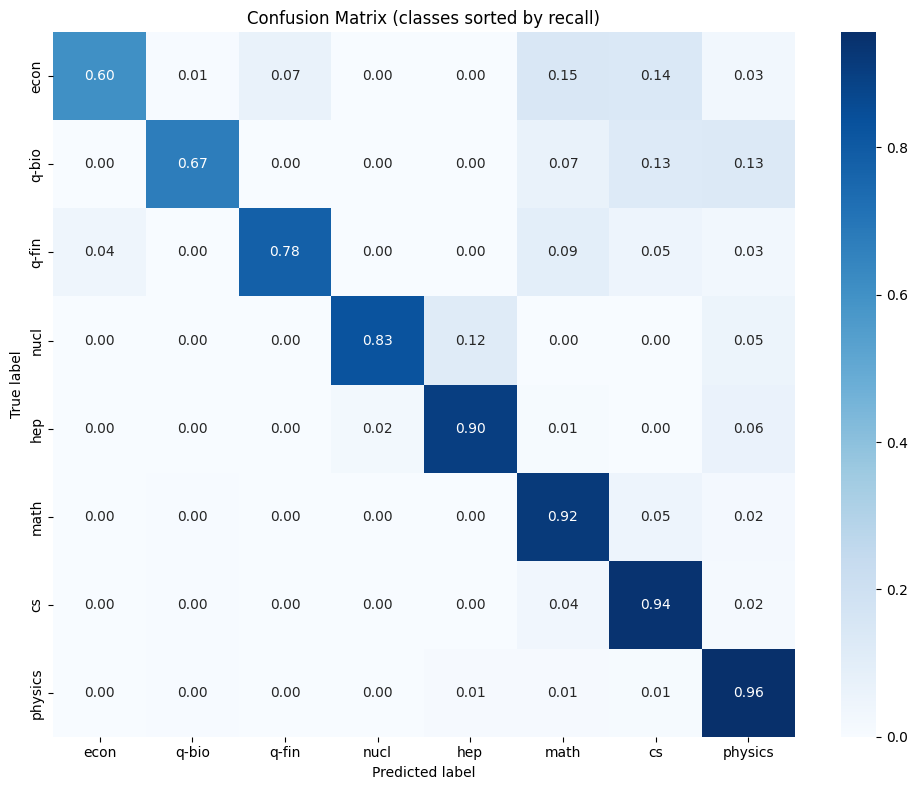

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort classes by diagonal (recall)
order = np.argsort(np.diag(cm))
cm_sorted = cm[order][:, order]
labels_sorted = [LABEL_NAMES[i] for i in order]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_sorted,
    xticklabels=labels_sorted,
    yticklabels=labels_sorted,
    cmap="Blues",
    annot=True,
    fmt=".2f"
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (classes sorted by recall)")
plt.tight_layout()
plt.show()

A value like 0.15 overlap between econ → math means that 15% of papers whose true label is econ are predicted as math.

Many econ papers:

* are heavy on optimization
* probability theory
* game theory
* mathematical proofs

From the model’s perspective vocabulary overlaps strongly with applied mathematics

econ ↔ cs (~0.14):

This usually comes from:

* algorithmic game theory
* mechanism design
* computational economics
* complexity / market simulations

q-bio ↔ cs and q-bio ↔ physics (~0.13)

q-bio includes:

* computational biology
* systems biology
* bioinformatics
* modeling of biological systems

nucl ↔ hep (~0.12)

This is probably the least surprising overlap of all:

* nuclear physics - high-energy physics - particle physics
* shared terminology: cross-sections, detectors, scattering, experiments


As expected, we observe:

- Strong diagonal for cs, math, physics
- Some hep <-> physics confusion (related fields)
- Some econ <-> q-fin confusion (related fields)
- Some nucl <-> hep confusion (related fields)
- Minimal leakage into unrelated domains

This is expected and healthy behavior for this classification task.

Most errors occur between conceptually adjacent scientific domains, suggesting that misclassifications reflect genuine interdisciplinary overlap rather than model confusion.

As expected, misclassifications are more often for underrepresented classes.

In comparison with TF-IDF we got:

* Improved performance overall, both in terms of accuracy and F1-score
* Much better, albeit not ideal, performance on minority classses